In [72]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import difflib
import json


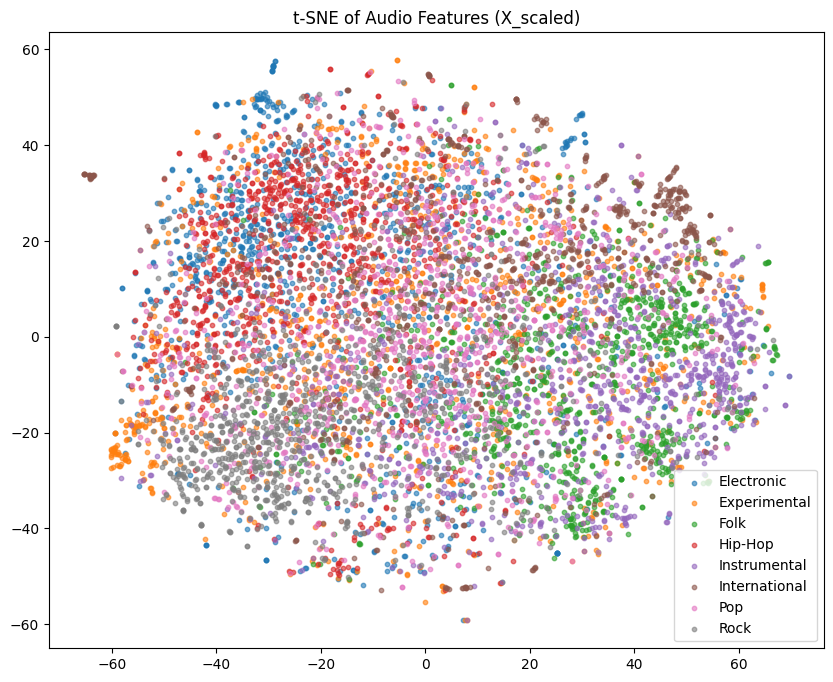

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

for i, genre in enumerate(unique_genres):
    idx = (y == i)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=10, alpha=0.6, label=genre)

plt.title("t-SNE X_scaled")
plt.legend()
plt.show()


In [34]:
data = np.load("fma_graph_data.npz", allow_pickle=True)

X_scaled    = data["X_scaled"]
y           = data["y"]
edge_index  = data["edge_index"]
idx_train   = data["idx_train"]
idx_val     = data["idx_val"]
idx_test    = data["idx_test"]
train_mask  = data["train_mask"]
val_mask    = data["val_mask"]
test_mask   = data["test_mask"]
unique_genres = data["unique_genres"]
genre_to_idx = dict(zip(data["genre_to_idx_keys"], data["genre_to_idx_vals"]))
track_ids     = data["track_ids"]
track_titles  = data["track_titles"]
track_artists = data["track_artists"]

In [3]:
X_scaled.shape, edge_index.shape, train_mask.sum(), val_mask.sum(), test_mask.sum()


((8000, 518), (2, 127949), np.int64(4800), np.int64(1600), np.int64(1600))

In [4]:
X_train = X_scaled[idx_train]
y_train = y[idx_train]

X_val = X_scaled[idx_val]
y_val = y[idx_val]

X_test = X_scaled[idx_test]
y_test = y[idx_test]

log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

log_reg.fit(X_train, y_train)

y_val_pred = log_reg.predict(X_val)
y_test_pred = log_reg.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average="macro")

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average="macro")

C:\Users\Gaming\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [5]:
print('Validation acc:', val_acc, 'F1:', val_f1)
print('Test acc:', test_acc, 'F1:', test_f1)

print(classification_report(y_test, y_test_pred, target_names=unique_genres))

Validation acc: 0.5225 F1: 0.5204691190234082
Test acc: 0.5325 F1: 0.5298629845845382
               precision    recall  f1-score   support

   Electronic       0.54      0.55      0.54       200
 Experimental       0.42      0.41      0.41       200
         Folk       0.60      0.64      0.62       200
      Hip-Hop       0.58      0.61      0.60       200
 Instrumental       0.56      0.52      0.54       200
International       0.60      0.64      0.62       200
          Pop       0.36      0.32      0.34       200
         Rock       0.56      0.59      0.58       200

     accuracy                           0.53      1600
    macro avg       0.53      0.53      0.53      1600
 weighted avg       0.53      0.53      0.53      1600



In [13]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [7]:
x = torch.from_numpy(X_scaled).float().to(device)
labels = torch.from_numpy(y).long().to(device)
edge_index_t = torch.from_numpy(edge_index).long().to(device)

print(f"x shape: {x.shape}")
print(f"labels shape: {labels.shape}")
print(f"edge_index_t shape: {edge_index_t.shape}")


x shape: torch.Size([8000, 518])
labels shape: torch.Size([8000])
edge_index_t shape: torch.Size([2, 127949])


In [14]:
N = x.size(0)

row, col = edge_index_t

self_loops = torch.arange(N, device=device)
self_loops = torch.stack([self_loops, self_loops], dim=0)

edge_index_with_loops = torch.cat([edge_index_t, self_loops], dim=1)

edge_weights = torch.ones(edge_index_with_loops.size(1), device=device)

row_all, col_all = edge_index_with_loops
deg = torch.bincount(row_all, minlength=N).float()

deg_inv_sqrt = deg.pow(-0.5)
deg_inv_sqrt[deg == 0] = 0.0

norm_weights = deg_inv_sqrt[row_all] * edge_weights * deg_inv_sqrt[col_all]


A_norm = torch.sparse_coo_tensor(
    edge_index_with_loops,
    norm_weights,
    size=(N, N),
    device=device
).coalesce()  

print(A_norm.shape)
print(A_norm._nnz())

torch.Size([8000, 8000])
135932


In [9]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=False)
        
    def forward(self, x, A_norm):
        support = self.linear(x)
        output = torch.sparse.mm(A_norm, support)
        return output

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout):
        super(GCN, self).__init__()
        self.gcn1 = GCNLayer(in_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, A_norm):
        h = self.gcn1(x, A_norm)
        h = F.relu(h)
        h = self.dropout(h)
        out = self.gcn2(h, A_norm)
        return out, h


In [16]:
in_dim = X_scaled.shape[1]
hidden_dim = 128
out_dim = len(unique_genres)
dropout = 0.5

model = GCN(in_dim, hidden_dim, out_dim, dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

train_mask_t = torch.from_numpy(train_mask).bool().to(device)
val_mask_t = torch.from_numpy(val_mask).bool().to(device)
test_mask_t = torch.from_numpy(test_mask).bool().to(device)

best_val_f1 = 0.0
patience = 20
patience_counter = 0
best_model_state = None

num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    
    logits, embeddings = model(x, A_norm)
    loss = criterion(logits[train_mask_t], labels[train_mask_t])
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            logits_eval, _ = model(x, A_norm)
            preds = logits_eval.argmax(dim=1)
            
            val_preds = preds[val_mask_t].cpu().numpy()
            val_labels = labels[val_mask_t].cpu().numpy()
            
            val_acc = accuracy_score(val_labels, val_preds)
            val_f1 = f1_score(val_labels, val_preds, average="macro")
            
            print('Epoch:',epoch, 'Loss:', loss.item(),'Val Acc:', val_acc, 'Val F1:', val_f1)
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)
                break

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch: 0 Loss: 2.1109867095947266 Val Acc: 0.241875 Val F1: 0.20143021752625806
Epoch: 9 Loss: 1.661881446838379 Val Acc: 0.42 Val F1: 0.37623751914335046
Epoch: 19 Loss: 1.5026636123657227 Val Acc: 0.45625 Val F1: 0.439747014979581
Epoch: 29 Loss: 1.4291794300079346 Val Acc: 0.475625 Val F1: 0.45750730430271763
Epoch: 39 Loss: 1.3790404796600342 Val Acc: 0.49875 Val F1: 0.48773455920212455
Epoch: 49 Loss: 1.3431336879730225 Val Acc: 0.503125 Val F1: 0.4919636230287571
Epoch: 59 Loss: 1.3133752346038818 Val Acc: 0.51125 Val F1: 0.5015294749063338
Epoch: 69 Loss: 1.2862478494644165 Val Acc: 0.51625 Val F1: 0.5068613675648378
Epoch: 79 Loss: 1.2627657651901245 Val Acc: 0.525 Val F1: 0.5162932219585661
Epoch: 89 Loss: 1.2443623542785645 Val Acc: 0.526875 Val F1: 0.5185066668981091
Epoch: 99 Loss: 1.2299777269363403 Val Acc: 0.5325 Val F1: 0.5249381454828159
Epoch: 109 Loss: 1.210396647453308 Val Acc: 0.53625 Val F1: 0.5286570930753327
Epoch: 119 Loss: 1.194509744644165 Val Acc: 0.535 Val 

In [18]:
model.eval()
with torch.no_grad():
    logits_final, embeddings_final = model(x, A_norm)
    preds_final = logits_final.argmax(dim=1)
    
    test_preds = preds_final[test_mask_t].cpu().numpy()
    test_labels = labels[test_mask_t].cpu().numpy()
    
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average="macro")
    
    print('GCN Test Acc:', test_acc, 'F1:',test_f1)
    print(classification_report(test_labels, test_preds, target_names=unique_genres))


GCN Test Acc: 0.5525 F1: 0.5466707278119732
               precision    recall  f1-score   support

   Electronic       0.52      0.55      0.53       200
 Experimental       0.49      0.43      0.46       200
         Folk       0.59      0.71      0.64       200
      Hip-Hop       0.57      0.59      0.58       200
 Instrumental       0.53      0.57      0.55       200
International       0.65      0.63      0.64       200
          Pop       0.39      0.28      0.33       200
         Rock       0.62      0.65      0.64       200

     accuracy                           0.55      1600
    macro avg       0.55      0.55      0.55      1600
 weighted avg       0.55      0.55      0.55      1600



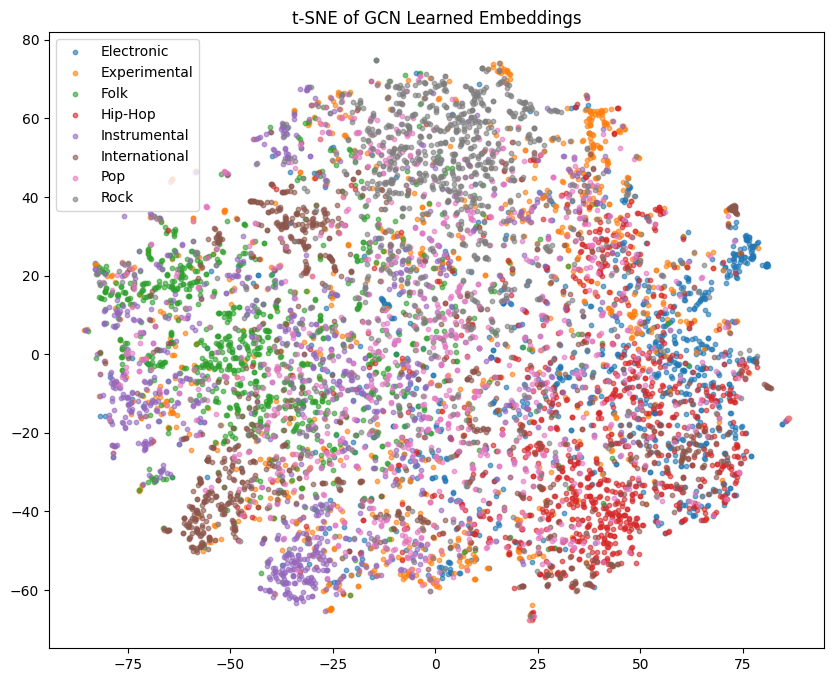

In [21]:
emb = embeddings_final.detach().cpu().numpy()

tsne_emb = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne_emb.fit_transform(emb)

plt.figure(figsize=(10, 8))

for i, genre in enumerate(unique_genres):
    idx = (y == i)
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], s=10, alpha=0.6, label=genre)

plt.title("t-SNE of GCN Learned Embeddings")
plt.legend()
plt.show()

In [23]:
node_embeddings = embeddings_final.detach().cpu().numpy()

def get_similar_tracks(track_idx, top_k=10):
    emb = node_embeddings
    v = emb[track_idx]
    sims = emb @ v / (np.linalg.norm(emb, axis=1) * np.linalg.norm(v) + 1e-8)
    order = np.argsort(-sims)
    similar = [i for i in order if i != track_idx][:top_k]
    return similar


In [24]:
from sklearn.model_selection import train_test_split

idx_train_labeled, _ = train_test_split(
    idx_train,
    test_size=0.9,
    stratify=y[idx_train],
    random_state=42
)

train_mask_semi = np.zeros(len(train_mask), dtype=bool)
train_mask_semi[idx_train_labeled] = True

print("train_mask sum:", train_mask.sum())
print("train_mask_semi sum:", train_mask_semi.sum())


train_mask sum: 4800
train_mask_semi sum: 480


In [25]:
X_train_semi = X_scaled[train_mask_semi]
y_train_semi = y[train_mask_semi]

X_val = X_scaled[idx_val]
y_val = y[idx_val]

X_test = X_scaled[idx_test]
y_test = y[idx_test]

log_reg_semi = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

log_reg_semi.fit(X_train_semi, y_train_semi)

y_val_pred_semi = log_reg_semi.predict(X_val)
y_test_pred_semi = log_reg_semi.predict(X_test)

val_acc_semi = accuracy_score(y_val, y_val_pred_semi)
val_f1_semi = f1_score(y_val, y_val_pred_semi, average="macro")

test_acc_semi = accuracy_score(y_test, y_test_pred_semi)
test_f1_semi = f1_score(y_test, y_test_pred_semi, average="macro")

print("LR semi val acc:", val_acc_semi)
print("LR semi val macro F1:", val_f1_semi)
print("LR semi test acc:", test_acc_semi)
print("LR semi test macro F1:", test_f1_semi)

lr_semi_test_acc = test_acc_semi
lr_semi_test_f1 = test_f1_semi


C:\Users\Gaming\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LR semi val acc: 0.423125
LR semi val macro F1: 0.4211316015150509
LR semi test acc: 0.425625
LR semi test macro F1: 0.42035381540035205


In [26]:
train_mask_semi_t = torch.from_numpy(train_mask_semi).bool().to(device)
val_mask_t = torch.from_numpy(val_mask).bool().to(device)
test_mask_t = torch.from_numpy(test_mask).bool().to(device)

model_semi = GCN(in_dim, hidden_dim, out_dim, dropout).to(device)
optimizer_semi = torch.optim.Adam(model_semi.parameters(), lr=1e-3, weight_decay=5e-4)
criterion_semi = nn.CrossEntropyLoss()

num_epochs_semi = 150

for epoch in range(num_epochs_semi):
    model_semi.train()
    optimizer_semi.zero_grad()
    
    logits, embeddings = model_semi(x, A_norm)
    loss = criterion_semi(logits[train_mask_semi_t], labels[train_mask_semi_t])
    
    loss.backward()
    optimizer_semi.step()
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        model_semi.eval()
        with torch.no_grad():
            logits_eval, _ = model_semi(x, A_norm)
            preds = logits_eval.argmax(dim=1)
            
            val_preds = preds[val_mask_t].cpu().numpy()
            val_labels = labels[val_mask_t].cpu().numpy()
            
            val_f1 = f1_score(val_labels, val_preds, average="macro")
            
            print("Epoch", epoch+1, "loss:", float(loss.item()), "val macro F1:", val_f1)

model_semi.eval()
with torch.no_grad():
    logits_final_semi, embeddings_semi = model_semi(x, A_norm)
    preds_final_semi = logits_final_semi.argmax(dim=1)
    
    test_preds_semi = preds_final_semi[test_mask_t].cpu().numpy()
    test_labels_semi = labels[test_mask_t].cpu().numpy()
    
    gcn_semi_acc = accuracy_score(test_labels_semi, test_preds_semi)
    gcn_semi_f1 = f1_score(test_labels_semi, test_preds_semi, average="macro")
    
    print("GCN semi test acc:", gcn_semi_acc)
    print("GCN semi test macro F1:", gcn_semi_f1)

gcn_semi_test_acc = gcn_semi_acc
gcn_semi_test_f1 = gcn_semi_f1


Epoch 1 loss: 2.086057186126709 val macro F1: 0.20580398209010337
Epoch 10 loss: 1.6037894487380981 val macro F1: 0.3482491532271245
Epoch 20 loss: 1.382625699043274 val macro F1: 0.3950791359053242
Epoch 30 loss: 1.2463338375091553 val macro F1: 0.414407803372126
Epoch 40 loss: 1.1446865797042847 val macro F1: 0.4281398701792872
Epoch 50 loss: 1.051170825958252 val macro F1: 0.4402685745214759
Epoch 60 loss: 0.9681279063224792 val macro F1: 0.4481054516590038
Epoch 70 loss: 0.9016675353050232 val macro F1: 0.44605158621103397
Epoch 80 loss: 0.8323477506637573 val macro F1: 0.4413485426891084
Epoch 90 loss: 0.7737281322479248 val macro F1: 0.4404649449180503
Epoch 100 loss: 0.6990785002708435 val macro F1: 0.4446622046163308
Epoch 110 loss: 0.6654761433601379 val macro F1: 0.43564102738673915
Epoch 120 loss: 0.5938456058502197 val macro F1: 0.44297631887386835
Epoch 130 loss: 0.5431115031242371 val macro F1: 0.4423152030088928
Epoch 140 loss: 0.5046650171279907 val macro F1: 0.43548031

In [27]:
X_train_full = X_scaled[idx_train]
y_train_full = y[idx_train]

log_reg_full = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

log_reg_full.fit(X_train_full, y_train_full)

y_test_pred_full = log_reg_full.predict(X_test)

lr_full_test_acc = accuracy_score(y_test, y_test_pred_full)
lr_full_test_f1 = f1_score(y_test, y_test_pred_full, average="macro")

model.eval()
with torch.no_grad():
    logits_full, _ = model(x, A_norm)
    preds_full = logits_full.argmax(dim=1)
    
    test_preds_gcn_full = preds_full[test_mask_t].cpu().numpy()
    test_labels_gcn_full = labels[test_mask_t].cpu().numpy()
    
    gcn_full_test_acc = accuracy_score(test_labels_gcn_full, test_preds_gcn_full)
    gcn_full_test_f1 = f1_score(test_labels_gcn_full, test_preds_gcn_full, average="macro")


C:\Users\Gaming\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


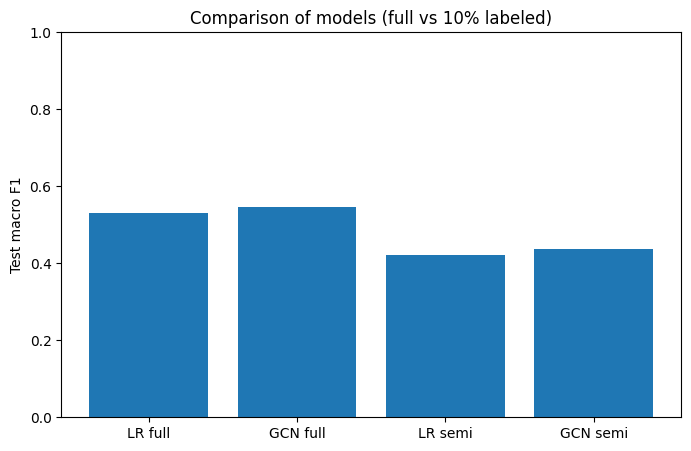

In [28]:
models = ["LR full", "GCN full", "LR semi", "GCN semi"]
f1_scores = [lr_full_test_f1, gcn_full_test_f1, lr_semi_test_f1, gcn_semi_test_f1]

plt.figure(figsize=(8, 5))
plt.bar(models, f1_scores)
plt.ylabel("Test macro F1")
plt.title("Comparison of models (full vs 10% labeled)")
plt.ylim(0.0, 1.0)
plt.show()


In [64]:
try:
    _ = track_artists
except NameError:
    data_meta = np.load("fma_graph_data.npz", allow_pickle=True)
    if "track_artists" in data_meta:
        track_artists = data_meta["track_artists"]
    else:
        track_artists = np.array([""] * len(track_titles))

print(len(y))
print(len(track_ids))
print(len(track_titles))
print(len(track_artists))




8000
106574
106574
106574


In [65]:
model.eval()
with torch.no_grad():
    logits_emb, embeddings_emb = model(x, A_norm)

embeddings_np = embeddings_emb.detach().cpu().numpy()

norms = np.linalg.norm(embeddings_np, axis=1, keepdims=True)
norms[norms == 0] = 1.0
node_embeddings_norm = embeddings_np / norms

print(node_embeddings_norm.shape)


(8000, 128)


In [66]:
def is_valid_index(idx):
    return 0 <= idx < len(y) and idx < len(track_ids) and idx < len(track_artists) and idx < len(track_titles)

def show_track_info(idx):
    if not is_valid_index(idx):
        return
    print("Index:", idx)
    print("Track ID:", track_ids[idx])
    print("Artist:", track_artists[idx])
    print("Title:", track_titles[idx])
    print("Genre:", unique_genres[y[idx]])

def find_track_indices_by_exact_title(title):
    title_lower = str(title).lower().strip()
    matches = []
    valid_range = len(y)
    for i in range(valid_range):
        if is_valid_index(i) and str(track_titles[i]).lower().strip() == title_lower:
            matches.append(i)
    
    if len(matches) == 0:
        print("No exact match", title)
        return []
    
    print(len(matches), "match")
    for idx in matches:
        if is_valid_index(idx):
            print("  idx:", idx, track_artists[idx], "-", track_titles[idx], "genre:", unique_genres[y[idx]])
    
    return matches


In [67]:
def get_similar_tracks_by_embedding(track_idx, top_k=5):
    if not is_valid_index(track_idx) or track_idx >= node_embeddings_norm.shape[0]:
        return [], []
    
    v = node_embeddings_norm[track_idx]
    
    similarities = node_embeddings_norm @ v
    
    similarities[track_idx] = -1.0
    
    max_valid_idx = min(len(y), node_embeddings_norm.shape[0])
    similarities[max_valid_idx:] = -2.0
    
    top_indices = np.argsort(-similarities)[:top_k * 2]
    
    valid_top_indices = [idx for idx in top_indices if is_valid_index(idx)][:top_k]
    valid_top_scores = [float(similarities[idx]) for idx in valid_top_indices]
    
    return valid_top_indices, valid_top_scores


In [68]:
def recommend_similar_songs_from_index(track_idx, top_k=5):
    if not is_valid_index(track_idx):
        return
    
    
    print("idx:", track_idx, track_artists[track_idx], "-", track_titles[track_idx], "genre:", unique_genres[y[track_idx]])
    
    similar_indices, similar_scores = get_similar_tracks_by_embedding(track_idx, top_k)
    
    for i, (idx, score) in enumerate(zip(similar_indices, similar_scores), 1):
        if is_valid_index(idx):
            print("idx:", idx, track_artists[idx], ",", track_titles[idx],"genre:", unique_genres[y[idx]], "sim:", float(score))
        else:
            print("no")

def recommend_similar_songs_from_title(title, top_k=5):
    matches = find_track_indices_by_exact_title(title)
    
    if len(matches) == 0:
        return
    
    selected_idx = matches[0]
    print()
    print(selected_idx, "-", track_titles[selected_idx])
    print()
    
    recommend_similar_songs_from_index(selected_idx, top_k)


In [69]:
recommend_similar_songs_from_index(123, top_k=5)


idx: 123 Blah Blah Blah - Going Down to Soho genre: Experimental
idx: 5902 Borromeo String Quartet , Mozart: Quartet No. 14 in G Major, Spring, K. 387 genre: Instrumental sim: 0.9039166569709778
idx: 7209 Mishoo the Drumkit , The Letter feat. Mr. Nnaji - Produced by Drumatic genre: Instrumental sim: 0.8736053705215454
idx: 3747 FortyOne , More Announcements genre: Electronic sim: 0.8697235584259033
idx: 571 Hans Grüsel's Krankenkabinet , Sechzig-Sechs genre: Folk sim: 0.8403225541114807
idx: 126 Blah Blah Blah , Think Things Of You genre: Folk sim: 0.8336575031280518


In [70]:
show_track_info(0)


Index: 0
Track ID: 2
Artist: AWOL
Title: Food
Genre: Hip-Hop


In [71]:
if len(track_titles) > 0:
    example_title = str(track_titles[0])
    recommend_similar_songs_from_title(example_title, top_k=5)


2 match
  idx: 0 AWOL - Food genre: Hip-Hop
  idx: 1173 Ric Royer &amp; G. Lucas Crane - Food genre: Electronic

0 - Food

idx: 0 AWOL - Food genre: Hip-Hop
idx: 7952 Goto80 , Love Crime genre: Hip-Hop sim: 0.8945660591125488
idx: 4437 Thee Oh Sees , Get Thy Bearings genre: Hip-Hop sim: 0.8820401430130005
idx: 7085 Sminky , Intro genre: Experimental sim: 0.8752028942108154
idx: 358 DJ's of Mass Destruction , WAR (If It Feels Good, Do It!) genre: Hip-Hop sim: 0.8602675795555115
idx: 1 AWOL , Electric Ave genre: Hip-Hop sim: 0.8593008518218994


In [73]:
top_k_similar = 5
tracks_data = []


for idx in range(N):
    if idx % 500 == 0:
        print(idx)
    
    if not is_valid_index(idx):
        continue
    
    track_id = str(track_ids[idx]) if idx < len(track_ids) else ""
    title = str(track_titles[idx]) if idx < len(track_titles) else ""
    artist = str(track_artists[idx]) if idx < len(track_artists) else ""
    genre = unique_genres[y[idx]] if idx < len(y) else ""
    
    similar_indices, similar_scores = get_similar_tracks_by_embedding(idx, top_k=top_k_similar)
    
    similar_tracks = []
    for sim_idx, sim_score in zip(similar_indices, similar_scores):
        if is_valid_index(sim_idx):
            similar_tracks.append({
                "idx": int(sim_idx),
                "similarity": float(sim_score)
            })
    
    track_entry = {
        "idx": int(idx),
        "id": track_id,
        "title": title,
        "artist": artist,
        "genre": genre,
        "similar_tracks": similar_tracks
    }
    
    tracks_data.append(track_entry)



0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500


In [ ]:
output_data = {
    "num_tracks": len(tracks_data),
    "tracks": tracks_data
}

output_filename = "music_recommendations.json"

with open(output_filename, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)


print(len(json.dumps(output_data)))


2968857
